In [ ]:
import os
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
)
import matplotlib.pyplot as plt

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

Using device: cpu
Mounted at /content/drive


In [ ]:
DERMNET_TEST_ROOT = "/content/dermnet_data_test"
CHECKPOINT_PATH = "/content/drive/MyDrive/skin_ai_app/best_model_stage1.pt"
RESULTS_DIR = "/content/drive/MyDrive/skin_ai_app/day6_results"
TEST_ZIP_DRIVE_PATH = "/content/drive/MyDrive/test.zip"
os.makedirs(RESULTS_DIR, exist_ok=True)

def ensure_test_data_unzipped():
    if os.path.isdir(DERMNET_TEST_ROOT) and any(Path(DERMNET_TEST_ROOT).iterdir()):
        print(f"{DERMNET_TEST_ROOT} already populated — skipping unzip.")
        return
    print(f"Unzipping test.zip -> {DERMNET_TEST_ROOT} ...")
    os.system(f"cp {TEST_ZIP_DRIVE_PATH} /content/test.zip")
    os.system(f"unzip -q /content/test.zip -d {DERMNET_TEST_ROOT}")
    print("Done.")

ensure_test_data_unzipped()

Unzipping test.zip -> /content/dermnet_data_test ...
Done.


In [ ]:
CLASS_FOLDER_MAP = {
    "Eczema": "Eczema Photos",
    "Hives": "Urticaria Hives",
    "Acne/Rosacea": "Acne and Rosacea Photos",
    "Psoriasis/Lichen Planus": "Psoriasis pictures Lichen Planus and related diseases",
    "Contact Dermatitis/Poison Ivy": "Poison Ivy Photos and other Contact Dermatitis",
    "Ringworm/Fungal Infections": "Tinea Ringworm Candidiasis and other Fungal Infections",
}
CLASS_NAMES = list(CLASS_FOLDER_MAP.keys())
NUM_CLASSES = len(CLASS_NAMES)
CONTACT_DERM_IDX = CLASS_NAMES.index("Contact Dermatitis/Poison Ivy")
MIN_RELIABLE_TEST_COUNT = 15

In [ ]:
def collect_filepaths(root):
    samples = []
    root_dir = Path(root)
    for class_idx, class_name in enumerate(CLASS_NAMES):
        folder = root_dir / CLASS_FOLDER_MAP[class_name]
        if not folder.exists():
            raise FileNotFoundError(f"Expected folder not found: {folder}")
        for ext in ("*.jpg", "*.jpeg", "*.png"):
            samples.extend((str(p), class_idx) for p in folder.glob(ext))
    return samples

test_samples = collect_filepaths(DERMNET_TEST_ROOT)
test_paths = [s[0] for s in test_samples]
test_labels = [s[1] for s in test_samples]

print(f"Test set: {len(test_paths)} images (expected 1416)")

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class SkinConditionDataset(Dataset):
    def __init__(self, filepaths, labels, transform):
        self.filepaths = filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = Image.open(self.filepaths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

test_ds = SkinConditionDataset(test_paths, test_labels, eval_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
model = models.efficientnet_b0(weights=None)  # weights loaded from checkpoint, not ImageNet
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)

checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, "
      f"val_macroF1={checkpoint['val_f1']:.3f}")

Loaded checkpoint from epoch 15, val_macroF1=0.535


In [ ]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        probs = torch.softmax(outputs, dim=1)
        preds = outputs.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_accuracy = accuracy_score(all_labels, all_preds)
test_precision, test_recall, test_f1, test_support = precision_recall_fscore_support(
    all_labels, all_preds, average=None, zero_division=0
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

print("FINAL TEST-SET RESULTS (first and only evaluation against holdout)")
print(f"Overall accuracy:  {test_accuracy:.3f}")
print(f"Macro precision:   {macro_precision:.3f}")
print(f"Macro recall:      {macro_recall:.3f}")
print(f"Macro F1:          {macro_f1:.3f}")

In [ ]:
print(f"\n{'Class':<35}{'Precision':>10}{'Recall':>10}{'F1':>10}{'Support':>10}  Reliability")
per_class_results = []
for i, name in enumerate(CLASS_NAMES):
    reliable = test_support[i] >= MIN_RELIABLE_TEST_COUNT
    flag = "" if reliable else "  <-- THIN, treat as noisy estimate"
    print(f"{name:<35}{test_precision[i]:>10.3f}{test_recall[i]:>10.3f}"
          f"{test_f1[i]:>10.3f}{test_support[i]:>10d}{flag}")
    per_class_results.append({
        "class": name,
        "precision": float(test_precision[i]),
        "recall": float(test_recall[i]),
        "f1": float(test_f1[i]),
        "support": int(test_support[i]),
        "reliable_sample_size": bool(reliable),
    })

cd_test_f1 = test_f1[CONTACT_DERM_IDX]
print(f"\nContact Dermatitis test F1: {cd_test_f1:.3f}  "
      f"(val-set history: 0.255 / 0.376 / 0.364; pre-set floor was 0.40)")


Confusion matrix (rows = true class, columns = predicted class):

                                      Eczema       Hives  Acne/Rosac  Psoriasis/  Contact De  Ringworm/F
Eczema                                   174           8          15          53          22          37
Hives                                      3          35           2           4           6           3
Acne/Rosacea                              17           6         223          16          21          29
Psoriasis/Lichen Planus                   59          23          25         140          29          76
Contact Dermatitis/Poison Ivy             13           7           4           2          34           5
Ringworm/Fungal Infections                30          19          29          49          18         180


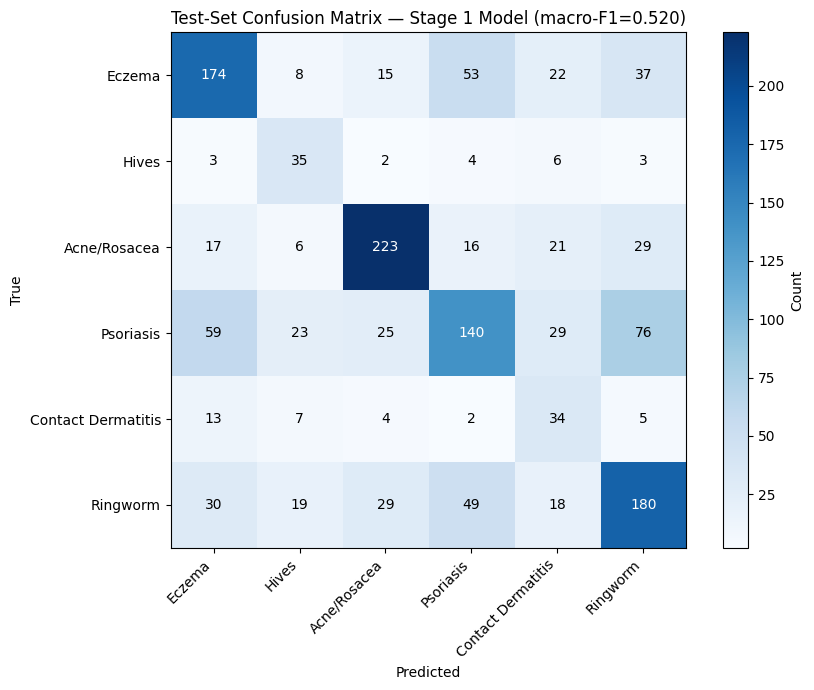


Confusion matrix plot saved to: /content/drive/MyDrive/skin_ai_app/day6_results/test_confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

print(f"\nConfusion matrix (rows = true class, columns = predicted class):\n")
header = " " * 32 + "".join(f"{n[:10]:>12}" for n in CLASS_NAMES)
print(header)
for i, name in enumerate(CLASS_NAMES):
    row = "".join(f"{cm[i][j]:>12d}" for j in range(NUM_CLASSES))
    print(f"{name:<32}{row}")

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(cm, cmap="Blues")
short_names = [n if len(n) <= 14 else n.split("/")[0] for n in CLASS_NAMES]
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(short_names, rotation=45, ha="right")
ax.set_yticklabels(short_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Test-Set Confusion Matrix — Stage 1 Model (macro-F1={macro_f1:.3f})")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")

fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, "test_confusion_matrix.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"\nConfusion matrix plot saved to: {plot_path}")